In [3]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

'''
pandas → Read and analyze CSV data.
numpy → Useful for handling missing values and numerical operations.
matplotlib → Create charts later in the notebook.
'''

Libraries imported successfully.


'\npandas → Read and analyze CSV data.\nnumpy → Useful for handling missing values and numerical operations.\nmatplotlib → Create charts later in the notebook.\n'

In [4]:
from google.colab import files

uploaded = files.upload()

Saving indian_households.csv to indian_households.csv


In [5]:
#check the file exists
import os

print(os.listdir())

['.config', 'indian_households.csv', 'sample_data']


In [6]:
# Load Dataset

dataset_path = "indian_households.csv"

print(f"Loading dataset from: {dataset_path}")

df_dataset = pd.read_csv(dataset_path)

print("Dataset loaded successfully!")

Loading dataset from: indian_households.csv
Dataset loaded successfully!


In [8]:
# Preview Dataset

print("First 5 Rows:")

df_dataset.head()

First 5 Rows:


,Household_ID,State,City,Family_Size,Monthly_Income,Monthly_Expense,Own_House,Education
0,HH001,Karnataka,Bengaluru,4,85000.0,52000.0,Yes,Graduate
1,HH002,Telangana,Hyderabad,5,72000.0,49000.0,No,Post Graduate
2,HH003,Tamil Nadu,Chennai,3,68000.0,42000.0,Yes,Graduate
3,HH004,Maharashtra,Mumbai,6,145000.0,98000.0,No,Post Graduate
4,HH005,Kerala,Kochi,4,76000.0,50000.0,Yes,Graduate


In [9]:
# Last 5 Rows

print("Last 6 Rows:")

df_dataset.tail(6)
#df_dataset.tail(2)

Last 6 Rows:


,Household_ID,State,City,Family_Size,Monthly_Income,Monthly_Expense,Own_House,Education
34,HH035,Kerala,Kochi,6,82000.0,56000.0,No,Graduate
35,HH036,Gujarat,Ahmedabad,4,94000.0,62000.0,Yes,Graduate
36,HH037,Delhi,New Delhi,3,128000.0,86000.0,Yes,Doctorate
37,HH038,Punjab,Ludhiana,5,79000.0,54000.0,Yes,Graduate
38,HH039,Rajasthan,Jaipur,4,72000.0,49000.0,No,Graduate
39,HH040,Rajasthan,Jaipur,4,72000.0,49000.0,No,Graduate


In [10]:
#Dataset shape

print("rows and columns")
print(df_dataset.shape)

rows and columns
(40, 8)


In [11]:
# Column Names

print("Columns in Dataset:")

print(df_dataset.columns)

Columns in Dataset:
Index(['Household_ID', 'State', 'City', 'Family_Size', 'Monthly_Income',
       'Monthly_Expense', 'Own_House', 'Education'],
      dtype='object')


In [12]:
# Dataset Information

print("Dataset Information")

df_dataset.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Household_ID     40 non-null     object 
 1   State            40 non-null     object 
 2   City             40 non-null     object 
 3   Family_Size      40 non-null     int64  
 4   Monthly_Income   39 non-null     float64
 5   Monthly_Expense  39 non-null     float64
 6   Own_House        40 non-null     object 
 7   Education        39 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 2.6+ KB


In [13]:
# 8. Descriptive Statistics

df_dataset.describe()

# mean , std dev , min , max , Q1 , Q2 , Q3

,Family_Size,Monthly_Income,Monthly_Expense
count,40.000000,39.000000,39.000000
mean,4.375000,82846.153846,55974.358974
std,1.004796,24494.401575,16907.623910
min,2.000000,56000.000000,36000.000000
25%,4.000000,67000.000000,45000.000000
50%,4.000000,74000.000000,50000.000000
75%,5.000000,88500.000000,61500.000000
max,6.000000,155000.000000,105000.000000


In [14]:
# 9. Missing Values

print("Missing Values in Each Column")

df_dataset.isnull().sum()

Missing Values in Each Column


,0
Household_ID,0
State,0
City,0
Family_Size,0
Monthly_Income,1
Monthly_Expense,1
Own_House,0
Education,1


In [15]:
# 10. Duplicate Rows

print("Duplicate Records")

print(df_dataset.duplicated().sum())

Duplicate Records
0


In [16]:
#CLEANING THE DATASET

# 11. Remove Duplicate Rows

print("Removing Duplicate Rows")
df_dataset = df_dataset.drop_duplicates()

print("Duplicate rows removed successfully.")

Removing Duplicate Rows
Duplicate rows removed successfully.


In [18]:
# 12. Fill Missing Income

income_median = df_dataset["Monthly_Income"].median()
#since media is less affected by unusually high data than mean

df_dataset["Monthly_Income"] = df_dataset["Monthly_Income"].fillna(income_median)

print("Missing Monthly Income filled with median.")

Missing Monthly Income filled with median.


In [19]:
# 13. Fill Missing Expense

expense_median = df_dataset["Monthly_Expense"].median()

df_dataset["Monthly_Expense"] = df_dataset["Monthly_Expense"].fillna(expense_median)

print("Missing Monthly Expense filled with median.")

Missing Monthly Expense filled with median.


In [20]:
# 14. Fill Missing Education

df_dataset["Education"] = df_dataset["Education"].fillna("Unknown")

print("Missing Education filled successfully.")

Missing Education filled successfully.


In [21]:
# 15. Verify Missing Values

print("Missing Values After Cleaning")

df_dataset.isnull().sum()

Missing Values After Cleaning


,0
Household_ID,0
State,0
City,0
Family_Size,0
Monthly_Income,0
Monthly_Expense,0
Own_House,0
Education,0


In [22]:
# 16. Cleaned Dataset Preview

df_dataset.head()

,Household_ID,State,City,Family_Size,Monthly_Income,Monthly_Expense,Own_House,Education
0,HH001,Karnataka,Bengaluru,4,85000.0,52000.0,Yes,Graduate
1,HH002,Telangana,Hyderabad,5,72000.0,49000.0,No,Post Graduate
2,HH003,Tamil Nadu,Chennai,3,68000.0,42000.0,Yes,Graduate
3,HH004,Maharashtra,Mumbai,6,145000.0,98000.0,No,Post Graduate
4,HH005,Kerala,Kochi,4,76000.0,50000.0,Yes,Graduate


In [23]:
# 17. Create Savings Column

df_dataset["Savings"] = (
    df_dataset["Monthly_Income"] - df_dataset["Monthly_Expense"]
)

print("Savings column created successfully!")

df_dataset.head()

Savings column created successfully!


,Household_ID,State,City,Family_Size,Monthly_Income,Monthly_Expense,Own_House,Education,Savings
0,HH001,Karnataka,Bengaluru,4,85000.0,52000.0,Yes,Graduate,33000.0
1,HH002,Telangana,Hyderabad,5,72000.0,49000.0,No,Post Graduate,23000.0
2,HH003,Tamil Nadu,Chennai,3,68000.0,42000.0,Yes,Graduate,26000.0
3,HH004,Maharashtra,Mumbai,6,145000.0,98000.0,No,Post Graduate,47000.0
4,HH005,Kerala,Kochi,4,76000.0,50000.0,Yes,Graduate,26000.0


In [24]:
# 18. High Income Households

high_income = df_dataset[df_dataset["Monthly_Income"] > 80000]

print("High Income Households:")

high_income

High Income Households:


,Household_ID,State,City,Family_Size,Monthly_Income,Monthly_Expense,Own_House,Education,Savings
0,HH001,Karnataka,Bengaluru,4,85000.0,52000.0,Yes,Graduate,33000.0
3,HH004,Maharashtra,Mumbai,6,145000.0,98000.0,No,Post Graduate,47000.0
5,HH006,Gujarat,Ahmedabad,5,90000.0,61000.0,Yes,Graduate,29000.0
6,HH007,Delhi,New Delhi,3,120000.0,80000.0,No,Doctorate,40000.0
7,HH008,Punjab,Ludhiana,6,83000.0,59000.0,Yes,High School,24000.0
12,HH013,Tamil Nadu,Coimbatore,4,81000.0,54000.0,Yes,Post Graduate,27000.0
13,HH014,Maharashtra,Pune,3,98000.0,64000.0,Yes,Graduate,34000.0
15,HH016,Gujarat,Surat,4,87000.0,60000.0,No,Diploma,27000.0
16,HH017,Delhi,New Delhi,2,135000.0,92000.0,Yes,Doctorate,43000.0
21,HH022,Telangana,Hyderabad,4,95000.0,68000.0,Yes,Graduate,27000.0


In [25]:
# 19. House Owners

house_owners = df_dataset[df_dataset["Own_House"] == "Yes"]

print("Households Owning a House:")

house_owners

Households Owning a House:


,Household_ID,State,City,Family_Size,Monthly_Income,Monthly_Expense,Own_House,Education,Savings
0,HH001,Karnataka,Bengaluru,4,85000.0,52000.0,Yes,Graduate,33000.0
2,HH003,Tamil Nadu,Chennai,3,68000.0,42000.0,Yes,Graduate,26000.0
4,HH005,Kerala,Kochi,4,76000.0,50000.0,Yes,Graduate,26000.0
5,HH006,Gujarat,Ahmedabad,5,90000.0,61000.0,Yes,Graduate,29000.0
7,HH008,Punjab,Ludhiana,6,83000.0,59000.0,Yes,High School,24000.0
8,HH009,Rajasthan,Jaipur,5,67000.0,43000.0,Yes,Diploma,24000.0
10,HH011,Karnataka,Mysuru,4,62000.0,39000.0,Yes,Graduate,23000.0
12,HH013,Tamil Nadu,Coimbatore,4,81000.0,54000.0,Yes,Post Graduate,27000.0
13,HH014,Maharashtra,Pune,3,98000.0,64000.0,Yes,Graduate,34000.0
14,HH015,Kerala,Thiruvananthapuram,5,73000.0,47000.0,Yes,Graduate,26000.0


In [26]:
# 20. Large Families

large_families = df_dataset[df_dataset["Family_Size"] >= 5]

print("Families with 5 or More Members:")

large_families

Families with 5 or More Members:


,Household_ID,State,City,Family_Size,Monthly_Income,Monthly_Expense,Own_House,Education,Savings
1,HH002,Telangana,Hyderabad,5,72000.0,49000.0,No,Post Graduate,23000.0
3,HH004,Maharashtra,Mumbai,6,145000.0,98000.0,No,Post Graduate,47000.0
5,HH006,Gujarat,Ahmedabad,5,90000.0,61000.0,Yes,Graduate,29000.0
7,HH008,Punjab,Ludhiana,6,83000.0,59000.0,Yes,High School,24000.0
8,HH009,Rajasthan,Jaipur,5,67000.0,43000.0,Yes,Diploma,24000.0
11,HH012,Telangana,Warangal,5,58000.0,41000.0,No,High School,17000.0
14,HH015,Kerala,Thiruvananthapuram,5,73000.0,47000.0,Yes,Graduate,26000.0
17,HH018,Punjab,Amritsar,6,64000.0,45000.0,No,High School,19000.0
18,HH019,Rajasthan,Jodhpur,5,61000.0,39000.0,Yes,Graduate,22000.0
20,HH021,Karnataka,Hubballi,5,78000.0,52000.0,Yes,Post Graduate,26000.0


In [27]:
# 21. Graduate Families

graduate_families = df_dataset[df_dataset["Education"] == "Graduate"]

print("Graduate Families:")

graduate_families

Graduate Families:


,Household_ID,State,City,Family_Size,Monthly_Income,Monthly_Expense,Own_House,Education,Savings
0,HH001,Karnataka,Bengaluru,4,85000.0,52000.0,Yes,Graduate,33000.0
2,HH003,Tamil Nadu,Chennai,3,68000.0,42000.0,Yes,Graduate,26000.0
4,HH005,Kerala,Kochi,4,76000.0,50000.0,Yes,Graduate,26000.0
5,HH006,Gujarat,Ahmedabad,5,90000.0,61000.0,Yes,Graduate,29000.0
9,HH010,West Bengal,Kolkata,4,70000.0,48000.0,No,Graduate,22000.0
10,HH011,Karnataka,Mysuru,4,62000.0,39000.0,Yes,Graduate,23000.0
13,HH014,Maharashtra,Pune,3,98000.0,64000.0,Yes,Graduate,34000.0
14,HH015,Kerala,Thiruvananthapuram,5,73000.0,47000.0,Yes,Graduate,26000.0
18,HH019,Rajasthan,Jodhpur,5,61000.0,39000.0,Yes,Graduate,22000.0
19,HH020,West Bengal,Durgapur,4,56000.0,36000.0,No,Graduate,20000.0


In [28]:
# 22. Sort by Monthly Income

sorted_income = df_dataset.sort_values(
    by="Monthly_Income",
    ascending=False
)

print("Top 10 Highest Income Households:")

sorted_income.head(10)

Top 10 Highest Income Households:


,Household_ID,State,City,Family_Size,Monthly_Income,Monthly_Expense,Own_House,Education,Savings
33,HH034,Maharashtra,Mumbai,4,155000.0,105000.0,Yes,Post Graduate,50000.0
3,HH004,Maharashtra,Mumbai,6,145000.0,98000.0,No,Post Graduate,47000.0
16,HH017,Delhi,New Delhi,2,135000.0,92000.0,Yes,Doctorate,43000.0
36,HH037,Delhi,New Delhi,3,128000.0,86000.0,Yes,Doctorate,42000.0
6,HH007,Delhi,New Delhi,3,120000.0,80000.0,No,Doctorate,40000.0
30,HH031,Karnataka,Bengaluru,3,112000.0,76000.0,No,Doctorate,36000.0
13,HH014,Maharashtra,Pune,3,98000.0,64000.0,Yes,Graduate,34000.0
21,HH022,Telangana,Hyderabad,4,95000.0,68000.0,Yes,Graduate,27000.0
35,HH036,Gujarat,Ahmedabad,4,94000.0,62000.0,Yes,Graduate,32000.0
5,HH006,Gujarat,Ahmedabad,5,90000.0,61000.0,Yes,Graduate,29000.0


In [29]:
# 22(b). Sort by Monthly Income

sorted_income = df_dataset.sort_values(
    by="Monthly_Income",
    ascending=True
)

print("Top 10 Lowest Income Households:")

sorted_income.head(10)

Top 10 Lowest Income Households:


,Household_ID,State,City,Family_Size,Monthly_Income,Monthly_Expense,Own_House,Education,Savings
19,HH020,West Bengal,Durgapur,4,56000.0,36000.0,No,Graduate,20000.0
11,HH012,Telangana,Warangal,5,58000.0,41000.0,No,High School,17000.0
22,HH023,Tamil Nadu,Madurai,6,59000.0,41000.0,No,Diploma,18000.0
18,HH019,Rajasthan,Jodhpur,5,61000.0,39000.0,Yes,Graduate,22000.0
31,HH032,Telangana,Nizamabad,4,61000.0,39000.0,Yes,Diploma,22000.0
10,HH011,Karnataka,Mysuru,4,62000.0,39000.0,Yes,Graduate,23000.0
29,HH030,West Bengal,Howrah,5,63000.0,42000.0,Yes,Graduate,21000.0
17,HH018,Punjab,Amritsar,6,64000.0,45000.0,No,High School,19000.0
27,HH028,Punjab,Jalandhar,6,66000.0,47000.0,Yes,High School,19000.0
8,HH009,Rajasthan,Jaipur,5,67000.0,43000.0,Yes,Diploma,24000.0


In [30]:
# 23. Sort by Savings

sorted_savings = df_dataset.sort_values(
    by="Savings",
    ascending=False
)

print("Top 10 Highest Savings:")

sorted_savings.head(10)

Top 10 Highest Savings:


,Household_ID,State,City,Family_Size,Monthly_Income,Monthly_Expense,Own_House,Education,Savings
33,HH034,Maharashtra,Mumbai,4,155000.0,105000.0,Yes,Post Graduate,50000.0
3,HH004,Maharashtra,Mumbai,6,145000.0,98000.0,No,Post Graduate,47000.0
16,HH017,Delhi,New Delhi,2,135000.0,92000.0,Yes,Doctorate,43000.0
36,HH037,Delhi,New Delhi,3,128000.0,86000.0,Yes,Doctorate,42000.0
6,HH007,Delhi,New Delhi,3,120000.0,80000.0,No,Doctorate,40000.0
30,HH031,Karnataka,Bengaluru,3,112000.0,76000.0,No,Doctorate,36000.0
13,HH014,Maharashtra,Pune,3,98000.0,64000.0,Yes,Graduate,34000.0
0,HH001,Karnataka,Bengaluru,4,85000.0,52000.0,Yes,Graduate,33000.0
35,HH036,Gujarat,Ahmedabad,4,94000.0,62000.0,Yes,Graduate,32000.0
5,HH006,Gujarat,Ahmedabad,5,90000.0,61000.0,Yes,Graduate,29000.0


In [31]:
# 24. Average Income by State

income_by_state = df_dataset.groupby("State")["Monthly_Income"].mean()

print("Average Monthly Income by State:")

income_by_state

Average Monthly Income by State:


,Monthly_Income
State,
Delhi,114250.0
Gujarat,88500.0
Karnataka,84250.0
Kerala,75500.0
Maharashtra,116750.0
Punjab,73000.0
Rajasthan,69200.0
Tamil Nadu,68750.0
Telangana,71500.0


In [32]:
# 25. Average Expense by State

expense_by_state = df_dataset.groupby("State")["Monthly_Expense"].mean()

print("Average Monthly Expense by State:")

expense_by_state

Average Monthly Expense by State:


,Monthly_Expense
State,
Delhi,80750.0
Gujarat,59500.0
Karnataka,54750.0
Kerala,49750.0
Maharashtra,78500.0
Punjab,51250.0
Rajasthan,46000.0
Tamil Nadu,45500.0
Telangana,49250.0


In [33]:
# 26. Average Savings by State

savings_by_state = df_dataset.groupby("State")["Savings"].mean()

print("Average Monthly Savings by State:")

savings_by_state

Average Monthly Savings by State:


,Savings
State,
Delhi,33500.0
Gujarat,29000.0
Karnataka,29500.0
Kerala,25750.0
Maharashtra,38250.0
Punjab,21750.0
Rajasthan,23200.0
Tamil Nadu,23250.0
Telangana,22250.0


In [34]:
# 27. Average Income by Education

education_income = df_dataset.groupby("Education")["Monthly_Income"].mean()

print("Average Income by Education Level:")

education_income

Average Income by Education Level:


,Monthly_Income
Education,
Diploma,68500.000000
Doctorate,123750.000000
Graduate,75666.666667
High School,67750.000000
Post Graduate,100833.333333
Unknown,71000.000000


In [35]:
# 28. Number of Households by State

state_count = df_dataset["State"].value_counts()

print("Number of Households in Each State:")

state_count

Number of Households in Each State:


,count
State,
Rajasthan,5
Karnataka,4
Telangana,4
Tamil Nadu,4
Kerala,4
Maharashtra,4
Gujarat,4
Delhi,4
Punjab,4


In [36]:
# 29. Summary Statistics

print("Total Households :", len(df_dataset))

print("Average Monthly Income :", df_dataset["Monthly_Income"].mean())

print("Average Monthly Expense :", df_dataset["Monthly_Expense"].mean())

print("Average Savings :", df_dataset["Savings"].mean())

print("Highest Income :", df_dataset["Monthly_Income"].max())

print("Lowest Income :", df_dataset["Monthly_Income"].min())

print("Highest Savings :", df_dataset["Savings"].max())

print("Lowest Savings :", df_dataset["Savings"].min())

Total Households : 40
Average Monthly Income : 82625.0
Average Monthly Expense : 55825.0
Average Savings : 26800.0
Highest Income : 155000.0
Lowest Income : 56000.0
Highest Savings : 50000.0
Lowest Savings : 9000.0


In [37]:
# 30. Create Output Folder

import os

os.makedirs("output", exist_ok=True)

print("Output folder is ready.")

Output folder is ready.


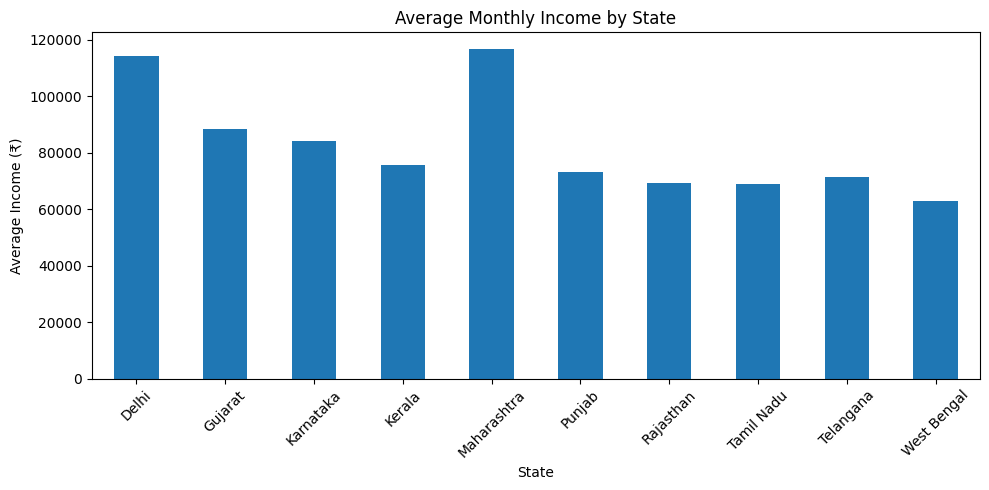

In [39]:
# Bar Chart : Average
# 31. Average Monthly Income by State

income_by_state.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Monthly Income by State")
plt.xlabel("State")
plt.ylabel("Average Income (₹)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("output/income_by_state.png")

plt.show()

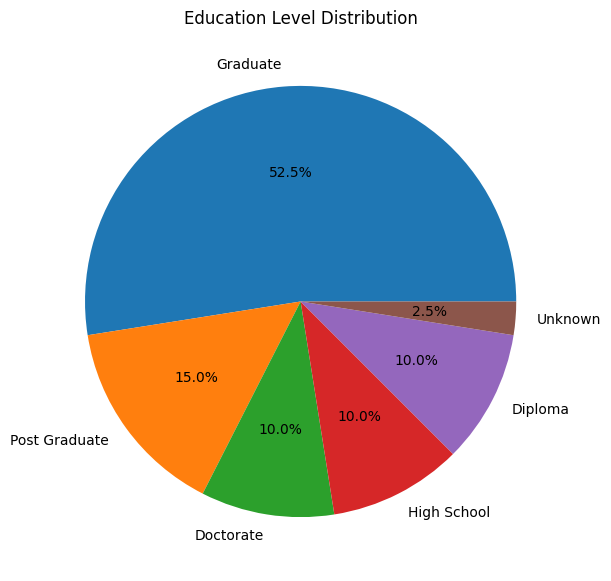

In [40]:
# Pie Chart : Distribution
# 32. Education Distribution

education_count = df_dataset["Education"].value_counts()

education_count.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("Education Level Distribution")

plt.ylabel("")

plt.savefig("output/education_distribution.png")

plt.show()

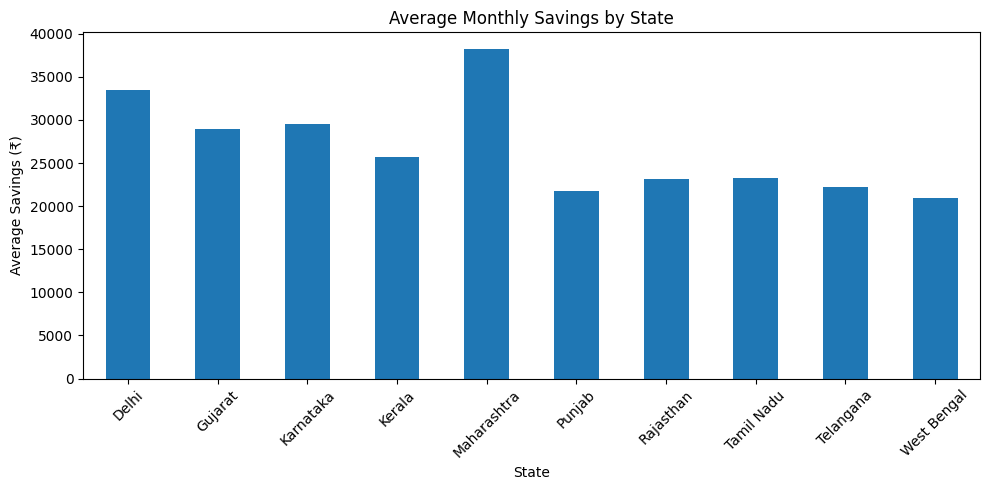

In [41]:
# 33. Average Savings by State

savings_by_state.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Monthly Savings by State")

plt.xlabel("State")

plt.ylabel("Average Savings (₹)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("output/savings_by_state.png")

plt.show()

In [42]:
# 34. Export Cleaned Dataset

df_dataset.to_csv(
    "output/cleaned_households.csv",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


In [43]:
# 35. Create Summary Report

summary = f"""
INDIAN HOUSEHOLD DATA ANALYSIS
==============================

Total Households : {len(df_dataset)}

Average Monthly Income : ₹{df_dataset['Monthly_Income'].mean():,.2f}

Average Monthly Expense : ₹{df_dataset['Monthly_Expense'].mean():,.2f}

Average Monthly Savings : ₹{df_dataset['Savings'].mean():,.2f}

Highest Income : ₹{df_dataset['Monthly_Income'].max():,.2f}

Lowest Income : ₹{df_dataset['Monthly_Income'].min():,.2f}

Highest Savings : ₹{df_dataset['Savings'].max():,.2f}

Lowest Savings : ₹{df_dataset['Savings'].min():,.2f}
"""

with open("output/summary.txt", "w") as file:
    file.write(summary)

print(summary)


INDIAN HOUSEHOLD DATA ANALYSIS

Total Households : 40

Average Monthly Income : ₹82,625.00

Average Monthly Expense : ₹55,825.00

Average Monthly Savings : ₹26,800.00

Highest Income : ₹155,000.00

Lowest Income : ₹56,000.00

Highest Savings : ₹50,000.00

Lowest Savings : ₹9,000.00



In [44]:
# 36. Key Insights

print("KEY INSIGHTS")
print("-" * 40)

print(f"• Total households analysed: {len(df_dataset)}")

print(f"• State with highest average income: {income_by_state.idxmax()}")

print(f"• State with highest average savings: {savings_by_state.idxmax()}")

print(f"• Most common education level: {education_count.idxmax()}")

print(f"• Highest monthly income: ₹{df_dataset['Monthly_Income'].max():,.0f}")

print(f"• Average monthly savings: ₹{df_dataset['Savings'].mean():,.0f}")

KEY INSIGHTS
----------------------------------------
• Total households analysed: 40
• State with highest average income: Maharashtra
• State with highest average savings: Maharashtra
• Most common education level: Graduate
• Highest monthly income: ₹155,000
• Average monthly savings: ₹26,800


In [47]:
# 37. Download All Output Files

from google.colab import files

print("Downloading cleaned dataset...")
files.download("output/cleaned_households.csv")

print("Downloading summary report...")
files.download("output/summary.txt")

print("Downloading Income by State chart...")
files.download("output/income_by_state.png")

print("Downloading Education Distribution chart...")
files.download("output/education_distribution.png")

print("Downloading Savings by State chart...")
files.download("output/savings_by_state.png")

print("\nAll project output files have been downloaded successfully!")
print("Please check your Downloads folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All project output files have been downloaded successfully!
Please check your Downloads folder.
